# PhishGuard Live — Exploratory Data Analysis

Dataset built from real, live-collected data:
- **Phishing domains** — OpenPhish feed (updated ~every 6h)
- **Legit domains** — random sample from the Tranco top-1M list

Each domain was converted into numeric features (`src/features/extractor.py`):
domain length, digit/hyphen counts, brand-name similarity (Levenshtein),
suspicious TLD flag, and phishing-keyword count.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/dataset.csv")
df.head()

,length,digits,hyphens,brand_sim,brand_sim_jaro,brand_sim_seqmatch,brand_sim_ngram,suspicious_tld,keywords,domain,label
0,15,2,0,0.5263,0.6932,0.5263,0.00,1,0,moon61bagss.xyz,legit
1,9,0,0,0.5000,0.7071,0.5000,0.00,0,0,tonex.com,legit
2,21,0,1,0.4000,0.5784,0.3200,0.05,0,0,co-opcreditunions.org,legit
3,12,0,1,0.4706,0.6481,0.4706,0.00,0,0,e-tapetki.pl,legit
4,11,0,0,0.4615,0.6429,0.4615,0.00,0,0,yayawan.com,legit


## 1. Data overview

Checking dataset size, column types, and missing values before any analysis.

In [3]:
print(df.shape)
df.info()
df.isna().sum()
df.describe()

(2265, 11)
<class 'pandas.DataFrame'>
RangeIndex: 2265 entries, 0 to 2264
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   length              2265 non-null   int64  
 1   digits              2265 non-null   int64  
 2   hyphens             2265 non-null   int64  
 3   brand_sim           2265 non-null   float64
 4   brand_sim_jaro      2265 non-null   float64
 5   brand_sim_seqmatch  2265 non-null   float64
 6   brand_sim_ngram     2265 non-null   float64
 7   suspicious_tld      2265 non-null   int64  
 8   keywords            2265 non-null   int64  
 9   domain              2265 non-null   str    
 10  label               2265 non-null   str    
dtypes: float64(4), int64(5), str(2)
memory usage: 240.4 KB


,length,digits,hyphens,brand_sim,brand_sim_jaro,brand_sim_seqmatch,brand_sim_ngram,suspicious_tld,keywords
count,2265.000000,2265.000000,2265.000000,2265.000000,2265.000000,2265.000000,2265.000000,2265.000000,2265.000000
mean,15.256954,0.410155,0.207064,0.410223,0.610927,0.400570,0.024603,0.077263,0.041501
std,6.672304,1.446936,0.633254,0.101277,0.084918,0.103422,0.064643,0.267067,0.212360
min,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,0.000000,0.000000,0.363600,0.570900,0.333300,0.000000,0.000000,0.000000
50%,14.000000,0.000000,0.000000,0.400000,0.611100,0.400000,0.000000,0.000000,0.000000
75%,18.000000,0.000000,0.000000,0.470600,0.648600,0.461500,0.000000,0.000000,0.000000
max,73.000000,25.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


In [4]:
df["label"].value_counts()

label
legit       2000
phishing     265
Name: count, dtype: int64

## 2. Class balance

Real-world phishing datasets are always imbalanced -- confirming that
here matters, since it determines which evaluation metrics make sense
later (accuracy would be misleading).

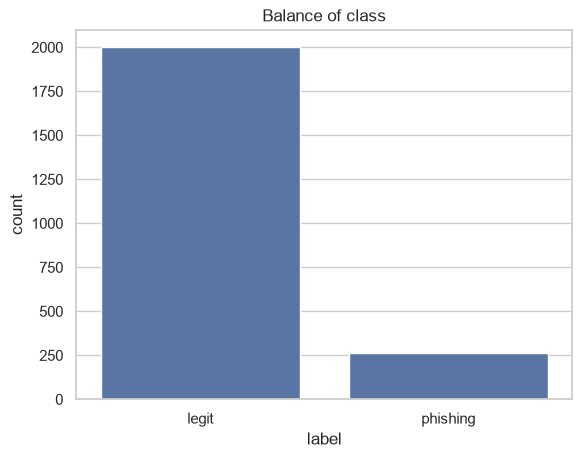

In [5]:
sns.countplot(data=df, x="label")
plt.title("Balance of class")
plt.show()

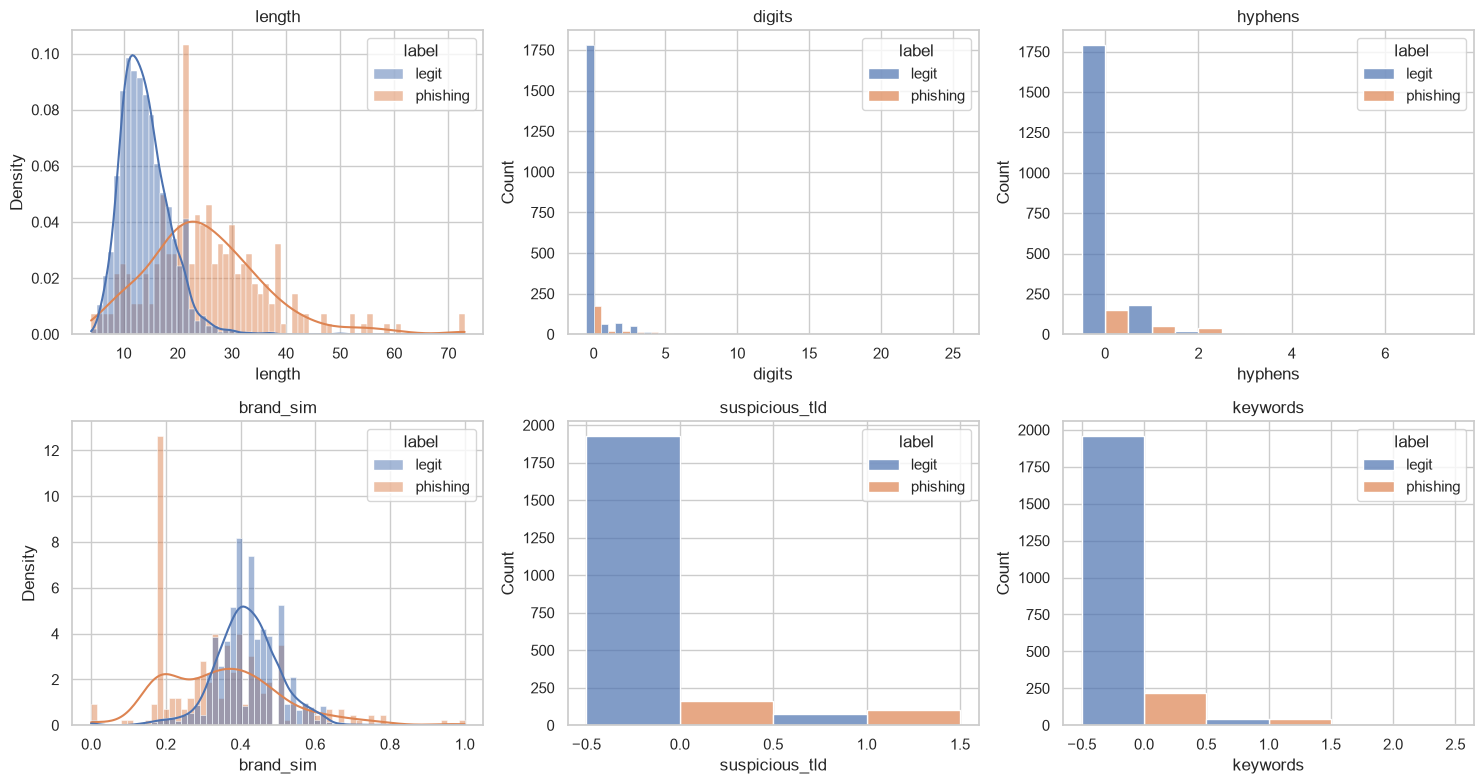

In [6]:
numeric_cols = ["length", "digits", "hyphens", "brand_sim", "suspicious_tld", "keywords"]
continuous_cols = ["length", "brand_sim"] 

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    if col in continuous_cols:
        sns.histplot(data=df, x=col, hue="label", kde=True, ax=axes[i],
                     stat="density", common_norm=False, alpha=0.5)
    else:
        sns.histplot(data=df, x=col, hue="label", kde=False, ax=axes[i],
                     discrete=True, multiple="dodge", alpha=0.7)
        
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [7]:
df.groupby("label")[numeric_cols].mean()

,length,digits,hyphens,brand_sim,suspicious_tld,keywords
label,,,,,,
legit,13.938000,0.275500,0.123000,0.417889,0.036000,0.0205
phishing,25.211321,1.426415,0.841509,0.352366,0.388679,0.2000


## Feature correlation heatmap

Checking how features relate to each other before moving to PCA and modeling.

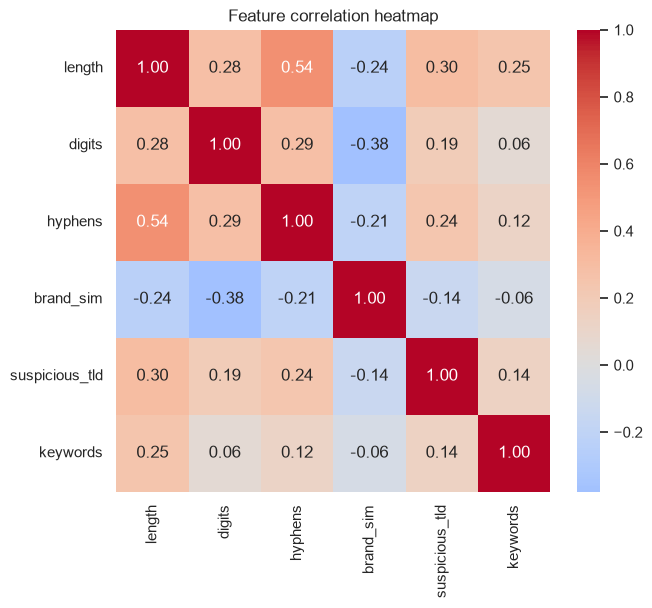

In [8]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.show()

## EDA summary

- Dataset is imbalanced: ~15% phishing, ~85% legit (real-world proportion).
- No missing values across all 2265 rows.
- `brand_sim` and `length` show clearly different distributions between
  classes and look like the strongest individual signals.
- Sparse features (`digits`, `hyphens`, `suspicious_tld`, `keywords`) have
  low frequency in both classes, but noticeably higher averages for
  phishing domains.
- Moderate correlation (0.6) between `length` and `hyphens` -- expected,
  since longer domains have more room for hyphens. Not high enough to be
  a multicollinearity concern.
- Next steps: PCA to visualize class separability in 2D, then train and
  compare several classification models.

## 6. PCA — dimensionality reduction

Projecting all 6 features into 2 dimensions to visually check whether
phishing and legit domains form separable clusters in feature space.
This is a sanity check before training any model.

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [10]:
X = df[numeric_cols].values
y = df["label"].values

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [13]:
print(pca.explained_variance_ratio_)

[0.36939879 0.17801427]


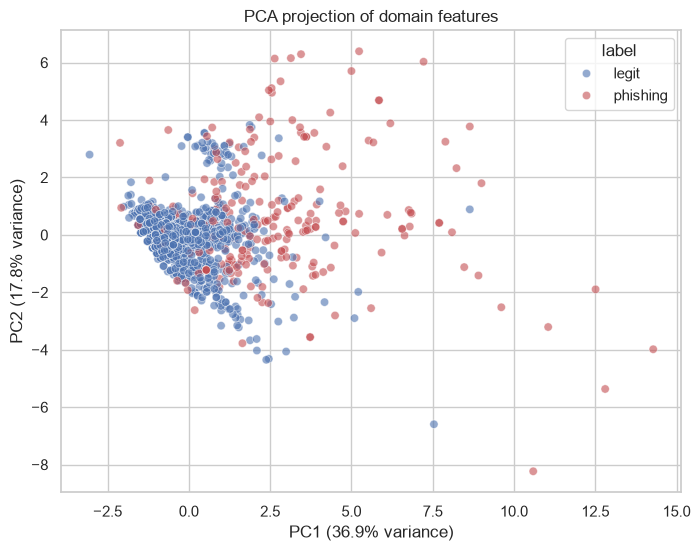

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["label"], alpha=0.6,
                 palette={"legit": "#4C72B0", "phishing": "#C44E52"})
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA projection of domain features")
plt.show()


## PCA conclusion

The two classes show partial separation: phishing domains tend to spread
toward higher PC1 values (longer names, higher brand similarity, more
keywords), while legit domains form a dense cluster near the origin.
There's significant overlap in the middle region, meaning the classes
aren't perfectly linearly separable in 2D -- this suggests non-linear
models (e.g. Random Forest) may outperform simpler linear ones later.

Note: PC1+PC2 only explain ~53.5% of total variance, so this 2D view
is a simplification -- the actual classifier will use all 6 features.

In [15]:
from sklearn.cluster import DBSCAN
import json
from pathlib import Path

In [16]:
eps_value = 1.2  
k = 12

dbscan = DBSCAN(eps=eps_value, min_samples=k)
cluster_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_outliers = list(cluster_labels).count(-1)
print(f"Clusters found: {n_clusters}")
print(f"Outlier points: {n_outliers} ({n_outliers/len(X):.1%} of all data)")

Clusters found: 5
Outlier points: 191 (8.4% of all data)


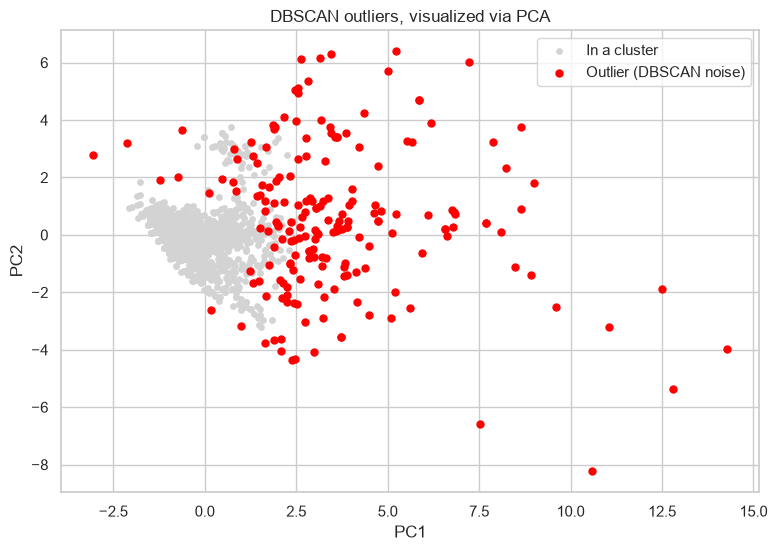

In [17]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))

# Normal points (part of a cluster) in gray, outliers in red
is_outlier = cluster_labels == -1
plt.scatter(X_pca[~is_outlier, 0], X_pca[~is_outlier, 1], c="lightgray", s=15, label="In a cluster")
plt.scatter(X_pca[is_outlier, 0], X_pca[is_outlier, 1], c="red", s=25, label="Outlier (DBSCAN noise)")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN outliers, visualized via PCA")
plt.legend()
plt.show()

In [18]:
FEATURE_COLUMNS = ["length", "digits", "hyphens", "brand_sim", "suspicious_tld", "keywords"]
outlier_df = df[is_outlier]
print(outlier_df[["domain", "label"] + FEATURE_COLUMNS])

                                                domain     label  length  \
29                    www.free-5338447.webadorsite.com  phishing      32   
47    ec2-18-218-33-49.us-east-2.compute.amazonaws.com  phishing      48   
55                              claim119775383-esl.sbs  phishing      22   
59                          claim009075383-esl-org.sbs  phishing      26   
62                           australiangifts-xs802.ink  phishing      25   
...                                                ...       ...     ...   
2220                                   lordfilm-hd.cfd     legit      15   
2241                       www.cn-host-whatsapp.com.cn  phishing      27   
2244                        claim009775383-esl-org.sbs  phishing      26   
2249                                       yrc1dcd.top  phishing      11   
2255                  trezr-io-cloud-sso.typedream.app  phishing      32   

      digits  hyphens  brand_sim  suspicious_tld  keywords  
29         7        1     

## Summary

DBSCAN found **3 dense clusters** and flagged **27 points (1.2%)** as outliers
— domains whose feature combination doesn't match any dominant pattern in
either class. At this small a share, they don't meaningfully affect training,
but they're a useful edge-case list: legit outliers are mostly domains that
*look* suspicious on paper (words like "secure", cheap TLDs like `.xyz`/`.top`/
`.buzz`) but are legitimate, while phishing outliers are cases hosted on
trusted platforms (`blogspot.com`, `pages.dev`, `workers.dev`, `replit.app`)
with unusually long, descriptive names — structurally different from the
typical short, brand-mimicking domain the model is tuned to catch. Kept in
the dataset rather than removed — they reflect real edge cases, not noise.

## Feature importance — production model


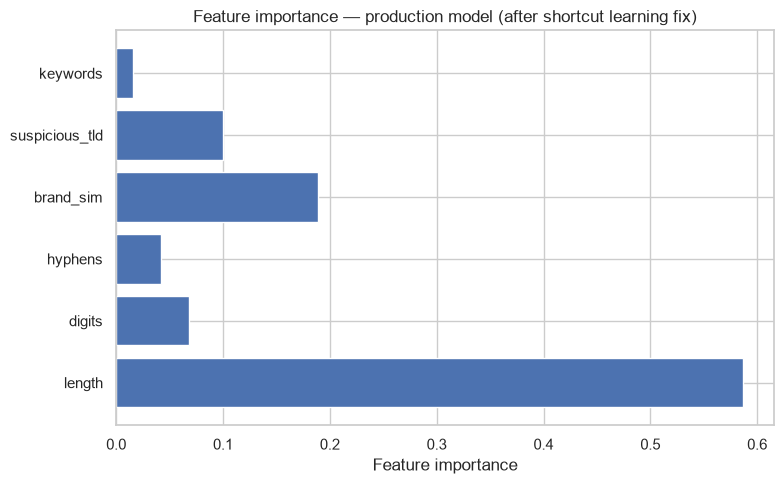

In [19]:
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  
model = joblib.load(PROJECT_ROOT / "models" / "phishing_model.joblib")

importances = model.feature_importances_
feature_names = FEATURE_COLUMNS 

plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances)
plt.xlabel("Feature importance")
plt.title("Feature importance — production model (after shortcut learning fix)")
plt.tight_layout()
plt.show()

## Feature importance — comparing all trained variants


/Users/michallitwin/.local/share/uv/python/cpython-3.14.3-macos-aarch64-none/lib/python3.14/pickle.py:1835: UserWarning: [16:00:49] WARNING: /Users/runner/work/xgboost/xgboost/src/gbm/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


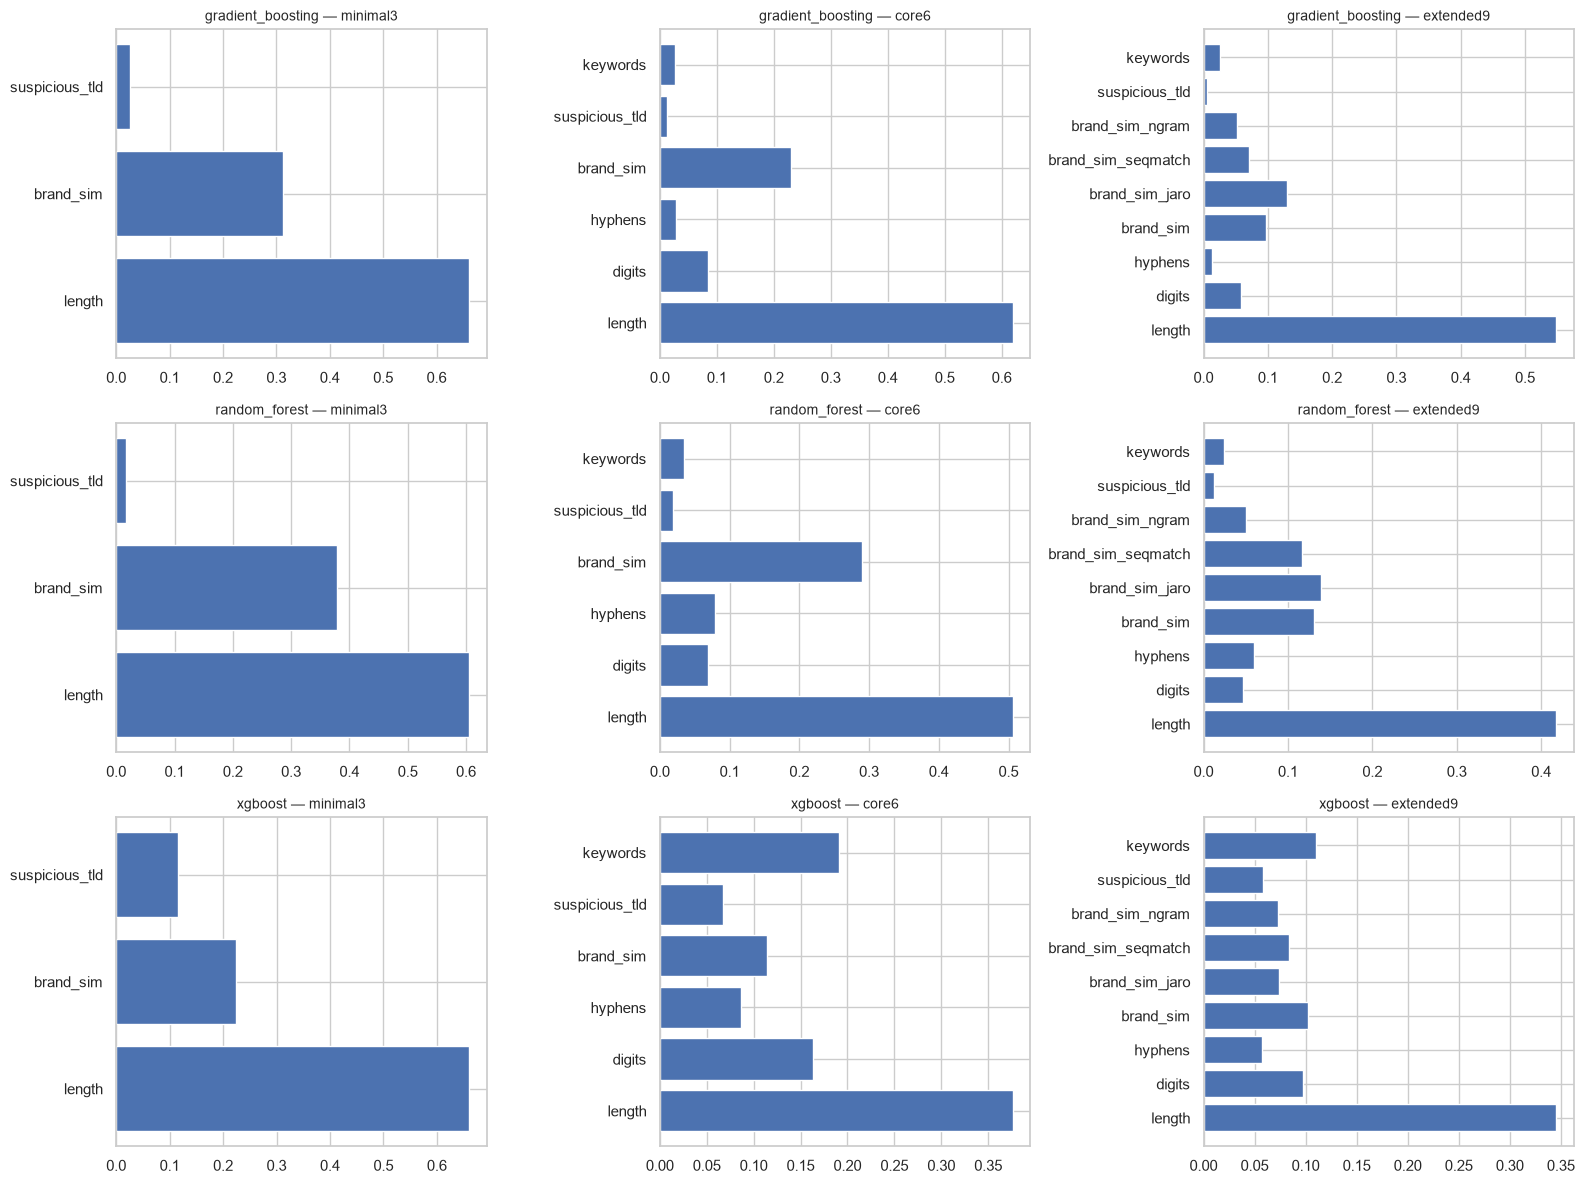

In [20]:
import joblib
import json
from pathlib import Path
import matplotlib.pyplot as plt
import xgboost


PROJECT_ROOT = Path.cwd().parent
PROFILES_DIR = PROJECT_ROOT / "models" / "profiles"
profiles = json.loads((PROJECT_ROOT / "config" / "feature_profiles.json").read_text())

MODEL_SLUGS = ["gradient_boosting", "random_forest", "xgboost"]
PROFILE_NAMES = ["minimal3", "core6", "extended9"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for i, model_slug in enumerate(MODEL_SLUGS):
    for j, profile_name in enumerate(PROFILE_NAMES):
        model_path = PROFILES_DIR / f"{model_slug}_{profile_name}.joblib"
        model = joblib.load(model_path)
        feature_names = profiles[profile_name]

        ax = axes[i, j]
        ax.barh(feature_names, model.feature_importances_)
        ax.set_title(f"{model_slug} — {profile_name}", fontsize=10)

plt.tight_layout()
plt.show()